In [7]:
from spin_lattices import KagomeLattice, SpinLattice, SquareLattice, TriangleLattice
from heisenberg_hamiltonians import HeisenbergJ1J2, SpinSystem
from fast_boolean_analysis import (
    keep_largest_n,
    keep_everything,
    ScorerType,
    get_scorer,
    FourierSeries,
)

import re

from lattice_boolean_analysis import (
    AmplitudeMedianBinSignalKind,
    SignSignalKind,
    AmplitudeSignalKind,
    SignalKind,
    LBFFromSpinSystem,
)

import json

from loguru import logger

from pathlib import Path
import numpy as np
import pandas as pd
import lattice_symmetries as ls
import matplotlib.pyplot as plt
from itertools import product
import numpy.typing as npt
from tqdm import tqdm
import seaborn as sns
import parse
import sys
from typing import NamedTuple
from utils import read_jsonl_to_df

from parity import popcount
from dataclasses import dataclass, astuple
from utils import get_abslargest_terms

ground_state_cache_dir = Path("groundstates")


In [121]:
def array_get(data, indexes, default_value=np.nan):
    mask = indexes < len(data)
    selected_values = np.take(data, indexes, mode='clip')
    new_array = np.where(mask, selected_values, default_value)
    return new_array

array_get(np.array([1, 10, 20, 30]), np.array([2, 1, 1, 7, 0]))

array([20., 10., 10., nan,  1.])

In [2]:
source_lattice = KagomeLattice(2, 3, enumerate_along="x")
destination_lattice = KagomeLattice(2, 4, enumerate_along="x")
rows = []

J2 = 0.8

source_system = HeisenbergJ1J2(
    lattice=source_lattice,
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    skip_symmetries_whitelist=True,
)
source_system.get_eigenstates(1)

destination_system = HeisenbergJ1J2(
    lattice=destination_lattice,
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    skip_symmetries_whitelist=True,
)
destination_system.get_eigenstates(1)

source_signal = LBFFromSpinSystem(source_system, kind=AmplitudeSignalKind())
destination_signal = LBFFromSpinSystem(destination_system, kind=AmplitudeSignalKind())

source_series = FourierSeries.from_signal(source_signal)
destination_series = FourierSeries.from_signal(destination_signal)

source_fourier_repr = source_lattice.get_fourier_basis_data()
destination_fourier_repr = destination_lattice.get_fourier_basis_data()

new_coeffs = np.zeros(2**destination_lattice.number_spins, dtype=np.float64)
new_coeffs[source_fourier_repr.reprs] = source_series.coeffs[source_fourier_repr.reprs]
new_representatives_coeffs = new_coeffs[destination_fourier_repr.reprs]

transferred_series = FourierSeries.from_representatives_coeffs(
    signal=destination_signal,
    coeffs=new_representatives_coeffs,
)

2023-05-17 18:12:52.825 | WARNING  | heisenberg_hamiltonians:__init__:415 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-05-17 18:12:52.826 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=18
2023-05-17 18:12:52.831 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 18:12:52.879 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 18:12:52.895 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-05-17 18:12:52.898 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energ

In [3]:
success, n_terms, _ = destination_series.how_many_terms_to_achieve_score(0.95, 'value_overlap')

2023-05-17 18:13:53.427 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:160 - min_terms=1, max_terms=16777216
2023-05-17 18:13:54.631 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:163 - mid=8388608, score=1.0000000000000002
2023-05-17 18:13:54.633 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:166 - score >= target_score, so we can decrease max_terms
2023-05-17 18:13:54.634 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:160 - min_terms=1, max_terms=8388608
2023-05-17 18:13:55.843 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:163 - mid=4194304, score=0.9980225253865909
2023-05-17 18:13:55.844 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:166 - score >= target_score, so we can decrease max_terms
2023-05-17 18:13:55.845 | DEBUG    | fast_boolean_analysis:how_many_terms_to_achieve_score:160 - min_terms=1, max_terms=4194304
2023-05-17 18:13:57.018 | DEBUG    | fast_boole

In [38]:
n_terms / (destination_series.coeffs > 0).sum()

0.2030206640862398

In [35]:
(source_series.coeffs > 0).sum()

65536

In [36]:
(transferred_series.coeffs > 0).sum()

98970

In [34]:
n_terms / destination_series.coeffs.shape[0]

0.05073440074920654

In [23]:
true_xors, true_coeffs = get_abslargest_terms(destination_series.coeffs, n_terms)

In [24]:
true_xors, true_coeffs

(array([16777215,        0, 12845055, ...,  4141469,  7380935, 14257155],
       dtype=uint64),
 array([ 0.1268275 ,  0.1268275 ,  0.03711559, ..., -0.0002669 ,
        -0.0002669 , -0.0002669 ]))

In [19]:
transferred_xors, transferred_coeffs = get_abslargest_terms(transferred_series.coeffs, n_terms)

In [22]:
transferred_xors.shape

(851182,)

In [21]:
transferred_xors[transferred_coeffs > 0].shape

(98970,)

In [30]:
true_transferred = set(transferred_xors[transferred_coeffs > 0]) & set(true_xors)

In [39]:
len(true_xors)

851182

In [31]:
len(true_transferred) / len(true_xors)

0.05018198223176712

In [32]:
len(true_transferred) / len(transferred_xors[transferred_coeffs > 0])

0.4315853288875417

In [12]:
source_series.coeffs.shape

(262144,)

In [143]:
source_lattice = KagomeLattice(2, 3, enumerate_along="x")
destination_lattice = KagomeLattice(2, 4, enumerate_along="x")
rows = []
for J2 in np.linspace(0, 1, 21):
    source_system = HeisenbergJ1J2(
        lattice=source_lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        skip_symmetries_whitelist=True,
    )
    source_system.get_eigenstates(1)

    destination_system = HeisenbergJ1J2(
        lattice=destination_lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        skip_symmetries_whitelist=True,
    )
    destination_system.get_eigenstates(1)

    source_signal = LBFFromSpinSystem(source_system, kind=AmplitudeSignalKind())
    destination_signal = LBFFromSpinSystem(destination_system, kind=AmplitudeSignalKind())

    source_series = FourierSeries.from_signal(source_signal)

    source_fourier_repr = source_lattice.get_fourier_basis_data()
    destination_fourier_repr = destination_lattice.get_fourier_basis_data()

    new_coeffs = np.zeros(2**destination_lattice.number_spins, dtype=np.float64)
    new_coeffs[source_fourier_repr.reprs] = source_series.coeffs[source_fourier_repr.reprs]
    new_representatives_coeffs = new_coeffs[destination_fourier_repr.reprs]

    transferred_series = FourierSeries.from_representatives_coeffs(
        signal=destination_signal,
        coeffs=new_representatives_coeffs,
    )

    score, _ = transferred_series.prediction_score(scorer="value_overlap")
    rows.append(
        {"J2": J2, "score": score, "iipr_source": 1 / source_series.ipr(ignore_free_term=True)}
    )

2023-05-17 17:05:18.404 | WARNING  | heisenberg_hamiltonians:__init__:415 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-05-17 17:05:18.405 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=18
2023-05-17 17:05:18.410 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:05:18.456 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:05:18.471 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.0-True-1-1.pickle
2023-05-17 17:05:18.473 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energ

<AxesSubplot: xlabel='J2'>

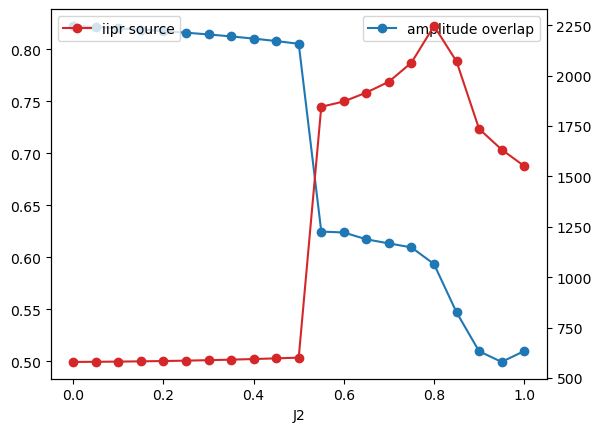

In [149]:
ax = pd.DataFrame(rows).plot(x="J2", y="score", marker="o", label="amplitude overlap")
pd.DataFrame(rows).plot(
    x="J2", y="iipr_source", marker="o", label="iipr source", ax=ax.twinx(), color="tab:red"
)

In [152]:
source_lattice = KagomeLattice(2, 3, enumerate_along="x")
destination_lattice = KagomeLattice(2, 4, enumerate_along="x")
rows = []
for J2 in np.linspace(0, 1, 21):
    source_system = HeisenbergJ1J2(
        lattice=source_lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        skip_symmetries_whitelist=True,
    )
    source_system.get_eigenstates(1)

    destination_system = HeisenbergJ1J2(
        lattice=destination_lattice,
        J1=1,
        J2=J2,
        use_symmetries=True,
        spin_inversion=1,
        ground_state_cache_dir=ground_state_cache_dir,
        skip_symmetries_whitelist=True,
    )
    destination_system.get_eigenstates(1)

    source_signal = LBFFromSpinSystem(source_system, kind=SignSignalKind())
    destination_signal = LBFFromSpinSystem(destination_system, kind=SignSignalKind())

    source_series = FourierSeries.from_signal(source_signal)

    source_fourier_repr = source_lattice.get_fourier_basis_data()
    destination_fourier_repr = destination_lattice.get_fourier_basis_data()

    new_coeffs = np.zeros(2**destination_lattice.number_spins, dtype=np.float64)
    new_coeffs[source_fourier_repr.reprs] = source_series.coeffs[source_fourier_repr.reprs]
    new_representatives_coeffs = new_coeffs[destination_fourier_repr.reprs]

    transferred_series = FourierSeries.from_representatives_coeffs(
        signal=destination_signal,
        coeffs=new_representatives_coeffs,
    )

    score, _ = transferred_series.prediction_score(scorer="sign_overlap")
    rows.append(
        {"J2": J2, "score": score, "iipr_source": 1 / source_series.ipr(ignore_free_term=True)}
    )

2023-05-17 17:12:33.336 | WARNING  | heisenberg_hamiltonians:__init__:415 - Symmetries are not tested with KagomeLattice2x3-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-05-17 17:12:33.337 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=18
2023-05-17 17:12:33.340 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 12 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:12:33.379 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 2102
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:12:33.394 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x3-enumerate-along-x-1.0-0.0-True-1-1.pickle
2023-05-17 17:12:33.396 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state energ

<AxesSubplot: xlabel='J2'>

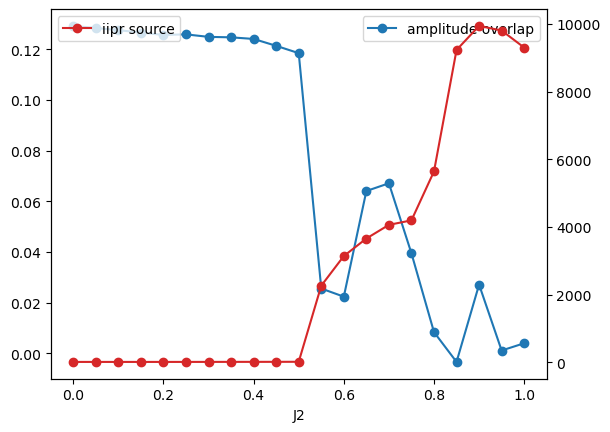

In [153]:
ax = pd.DataFrame(rows).plot(x="J2", y="score", marker="o", label="amplitude overlap")
pd.DataFrame(rows).plot(
    x="J2", y="iipr_source", marker="o", label="iipr source", ax=ax.twinx(), color="tab:red"
)

In [154]:
source_lattice = KagomeLattice(2, 4, enumerate_along="x")
destination_lattice = KagomeLattice(2, 5, enumerate_along="x")
J2 = 0.8
source_system = HeisenbergJ1J2(
    lattice=source_lattice,
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    skip_symmetries_whitelist=True,
)
source_system.get_eigenstates(1)

destination_system = HeisenbergJ1J2(
    lattice=destination_lattice,
    J1=1,
    J2=J2,
    use_symmetries=True,
    spin_inversion=1,
    ground_state_cache_dir=ground_state_cache_dir,
    skip_symmetries_whitelist=True,
)
destination_system.get_eigenstates(1)

source_signal = LBFFromSpinSystem(source_system, kind=AmplitudeSignalKind())
destination_signal = LBFFromSpinSystem(destination_system, kind=AmplitudeSignalKind())

source_series = FourierSeries.from_signal(source_signal)

source_fourier_repr = source_lattice.get_fourier_basis_data()
destination_fourier_repr = destination_lattice.get_fourier_basis_data()

new_coeffs = np.zeros(2**destination_lattice.number_spins, dtype=np.float64)
new_coeffs[source_fourier_repr.reprs] = source_series.coeffs[source_fourier_repr.reprs]
new_representatives_coeffs = new_coeffs[destination_fourier_repr.reprs]

transferred_series = FourierSeries.from_representatives_coeffs(
    signal=destination_signal,
    coeffs=new_representatives_coeffs,
)

score, _ = transferred_series.prediction_score(scorer="value_overlap")
score

2023-05-17 17:17:33.544 | WARNING  | heisenberg_hamiltonians:__init__:415 - Symmetries are not tested with KagomeLattice2x4-enumerate-along-x, and can produce incorrect results. Using them anyway due to skip_symmetries_whitelist=True.
2023-05-17 17:17:33.545 | DEBUG    | heisenberg_hamiltonians:__init__:448 - number_spins=24
2023-05-17 17:17:33.549 | DEBUG    | heisenberg_hamiltonians:__init__:458 - Symmetry group contains 16 elements
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:17:33.616 | DEBUG    | heisenberg_hamiltonians:__init__:467 - Hilbert space dimension is 85662
[Debug]   [LOCALE0]   ls_chpl_enumerate_representatives ...
2023-05-17 17:17:33.716 | DEBUG    | heisenberg_hamiltonians:_find_cached_eigenstate:60 - Using cached version of eigenvalues / eigenstates from groundstates/HeisenbergJ1J2-KagomeLattice2x4-enumerate-along-x-1.0-0.8-True-1-1.pickle
2023-05-17 17:17:33.723 | DEBUG    | heisenberg_hamiltonians:get_eigenstates:107 - Ground state ener

: 

: 